<a href="https://colab.research.google.com/github/vitor-laudares/Trabalho-Final-Py_Stellantis/blob/main/trabalho_final_py_stellantis_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Trabalho final da disciplina de programação em Python

Alunos:

Anna Beatriz

Joao Pedro

Matheus Rocha

Pedro Henrique

Vitor Laudares


---




## Tema: Emissão de CO2 por veículos

O dataset escolhido, apresenta mais de 7 mil carros de diferentes montadoras. As características presentes são:

Make

Model

Vehicle Class

Engine Size(L)

Cylinders

Transmission

Fuel Type

Fuel Consumption City (L/100 km)

Fuel Consumption Hwy (L/100 km)

Fuel Consumption Comb (L/100 km)

Fuel Consumption Comb (mpg)

CO2 Emissions(g/km)

Vizualizações:

Modelo que passou no limite x Valor do teste

Grupo de marcas x Emissão

Tipo de combustível x consumo estrada x consumo cidade

Histograma eficiencia energetica

Cambio x Eficiência


dificuldades:encontrar a tradução dos códigos de combustivel


In [63]:
# Imports e carregamento do arquivo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('co2.csv')

# No data.info, vemos que não existem buracos nem dados faltantes
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [64]:
# Conversão de L/100km para km/L
colunas_consumo = ['Fuel Consumption City (L/100 km)',
                   'Fuel Consumption Hwy (L/100 km)',
                   'Fuel Consumption Comb (L/100 km)']
for coluna in colunas_consumo:
    data[coluna] = 100 / data[coluna]
    data.rename(columns={coluna: coluna.replace('L/100 km', 'km/L')}, inplace=True)
# data.info()


#Conversão dos Códigos de combustível
lista_combustiveis = []
for sigla in data['Fuel Type']:
    if sigla == 'D':
        lista_combustiveis.append('Diesel')
    elif sigla == 'E':
        lista_combustiveis.append('Etanol')
    elif sigla == 'N':
        lista_combustiveis.append('Gás Natural')
    elif sigla == 'X':
        lista_combustiveis.append('Gasolina Comum')
    elif sigla == 'Z':
        lista_combustiveis.append('Gasolina Premium')
    else:
        lista_combustiveis.append('Outros')
data['Fuel Type'] = lista_combustiveis


# Junção das marcas em grupos
stellantis_marcas = ['CHRYSLER', 'DODGE', 'FIAT', 'JEEP', 'RAM', 'ALFA ROMEO', 'MASERATI']
gm_marcas = ['CHEVROLET', 'BUICK', 'CADILLAC', 'GMC']
data.loc[data['Make'] == 'SRT', 'Make'] = 'DODGE'
lista_marcas = data['Make'].unique()

vw_marcas = ['VOLKSWAGEN', 'AUDI', 'PORSCHE', 'LAMBORGHINI', 'BENTLEY']
toyota_marcas = ['TOYOTA', 'LEXUS']
hyundai_marcas = ['HYUNDAI', 'KIA', 'GENESIS']
bmw_marcas = ['BMW', 'MINI', 'ROLLS-ROYCE']
ford_marcas = ['FORD', 'LINCOLN']
honda_marcas = ['HONDA', 'ACURA']




/tmp/ipykernel_1623/1479008677.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='CO2 Emissions(g/km)', data=data, palette='viridis')


<Figure size 1200x600 with 0 Axes>

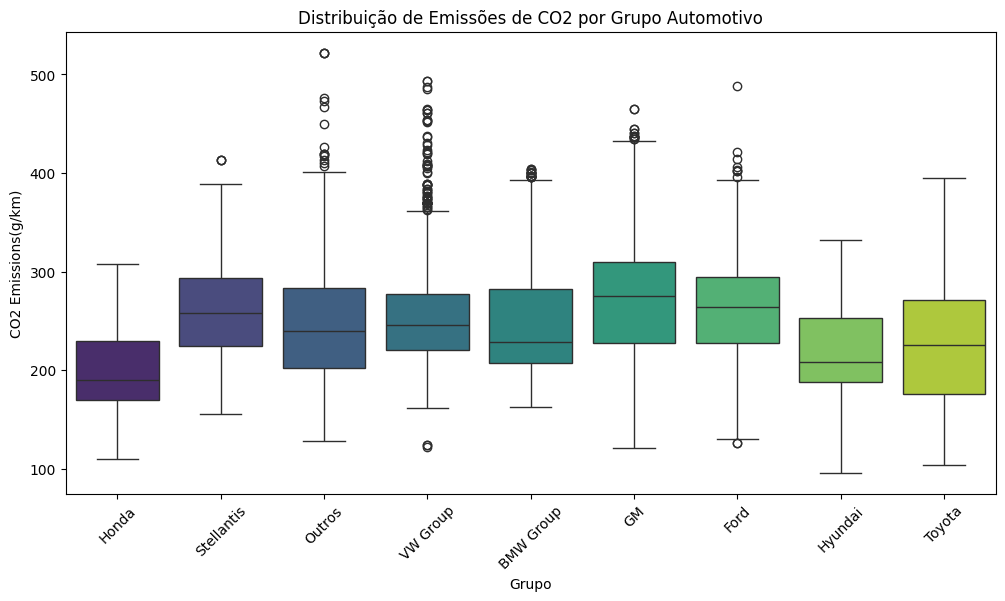

In [66]:
lista_de_grupos = []
for marca in data['Make']:
    if marca in stellantis_marcas:
        lista_de_grupos.append('Stellantis')
    elif marca in gm_marcas:
        lista_de_grupos.append('GM')
    elif marca in vw_marcas:
        lista_de_grupos.append('VW Group')
    elif marca in toyota_marcas:
        lista_de_grupos.append('Toyota')
    elif marca in hyundai_marcas:
        lista_de_grupos.append('Hyundai')
    elif marca in bmw_marcas:
        lista_de_grupos.append('BMW Group')
    elif marca in ford_marcas:
        lista_de_grupos.append('Ford')
    elif marca in honda_marcas:
        lista_de_grupos.append('Honda')
    else:
        lista_de_grupos.append('Outros')

data['Grupo'] = lista_de_grupos

plt.figure(figsize=(12, 6))

plt.figure(figsize=(12, 6))
sns.boxplot(x='Grupo', y='CO2 Emissions(g/km)', data=data, palette='viridis')

plt.title('Distribuição de Emissões de CO2 por Grupo Automotivo')
plt.xticks(rotation=45)
plt.show()



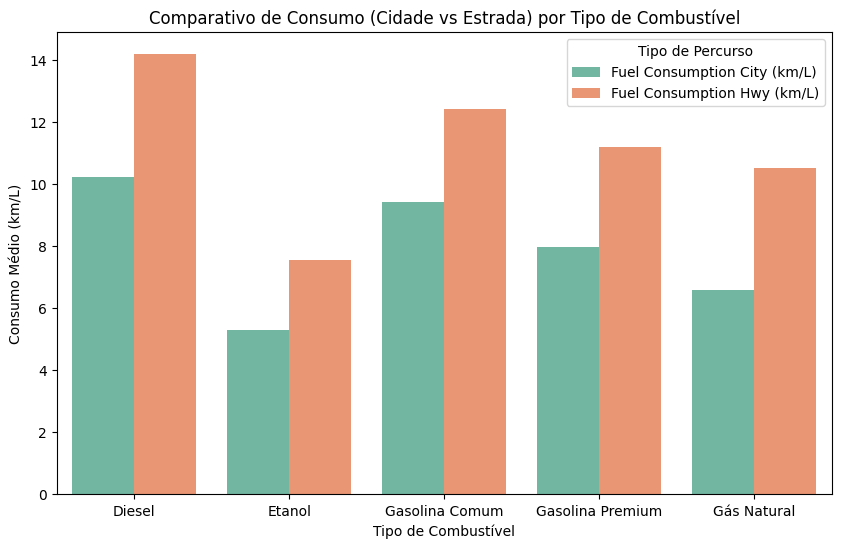

In [65]:
dados_agrupados = data.groupby('Fuel Type')[['Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)']].mean()

dados_agrupados = dados_agrupados.reset_index()

dados_longo = dados_agrupados.melt(id_vars='Fuel Type',
                                   value_vars=['Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)'],
                                   var_name='Tipo de Percurso',
                                   value_name='Consumo (km/L)')

plt.figure(figsize=(10, 6))
sns.barplot(x='Fuel Type', y='Consumo (km/L)', hue='Tipo de Percurso', data=dados_longo, palette='Set2')

plt.title('Comparativo de Consumo (Cidade vs Estrada) por Tipo de Combustível')
plt.xlabel('Tipo de Combustível')
plt.ylabel('Consumo Médio (km/L)')
plt.show()

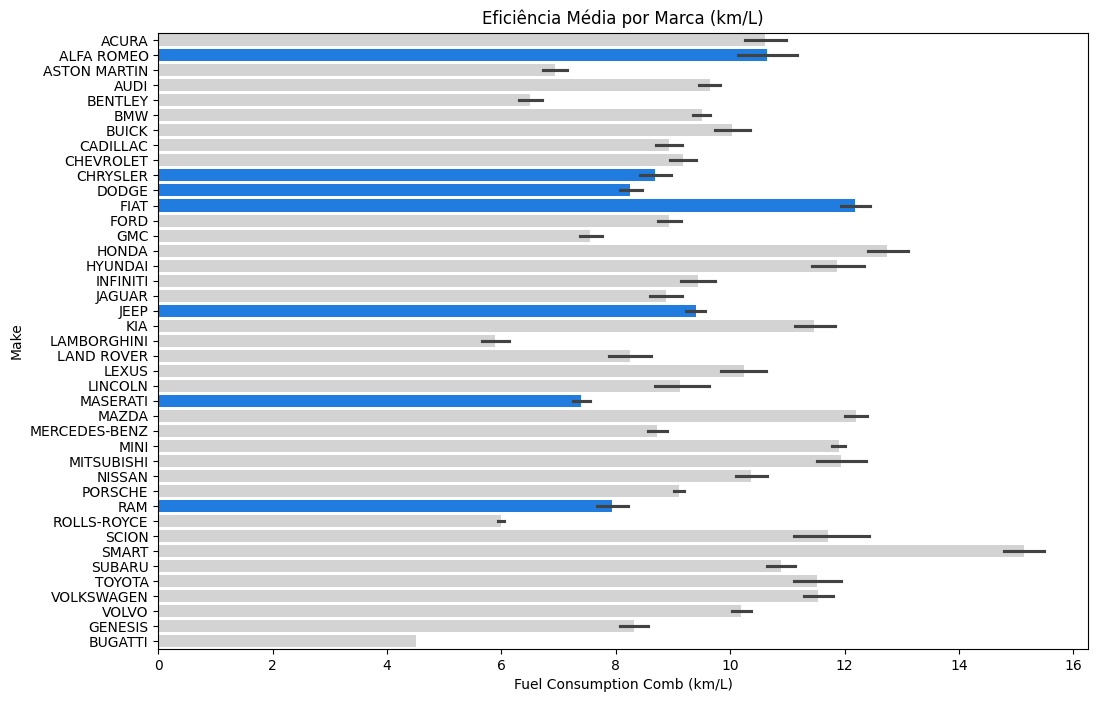

In [40]:
# cores = {}
# # Percorre a lista de marcas
# for marca in lista_marcas:
#     # Aplica a verificação se a marca está no grupo stellantes
#     if marca in stellantis_marcas:
#         cores[marca] = '#007bff'  # Cor Stellantis
#     else:
#         cores[marca] = '#d3d3d3'  # Cor Cinza (outras marcas)
# plt.figure(figsize=(12, 8))
# sns.barplot(
#     data=data,
#     x='Fuel Consumption Comb (km/L)',
#     y='Make',
#     hue='Make',
#     palette=cores,
#     legend=False
# )

# plt.title('Eficiência Média por Marca (km/L)')
# plt.show()
